# Dotting Models Domain Sensitivity Analysis

This notebook analyzes the performance of different dotting models across various text domains.
We compare:
- Sequence Labeling: LSTM with 4 layers (best model)
- N-gram Language Model: 8-gram with beam size 60 (best trade-off considering inference time)
- LLM-based: Claude Sonnet 4 with 8-shot (best LLM model)

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

## Load Results

In [2]:
# Define paths to result files
results_paths = {
    'LSTM (4 layers)': 'tnqeet/dotting_models/sequence_labeling/evaluation_results/test_dataset/LSTM_layers_4_results.json',
    'N-gram (8-gram, beam=60)': 'tnqeet/dotting_models/ngrams/evaluation_results/test_dataset/beam_size_60/ngrams_8.json',
    'LLM (Claude Sonnet 4)': 'tnqeet/dotting_models/llms/evaluation_results/test_dataset/fewshot_8/default_prompt/claude-sonnet-4.json'
}

# Load results
results = {}
for model_name, path in results_paths.items():
    full_path = Path(path)
    if full_path.exists():
        with open(full_path, 'r', encoding='utf-8') as f:
            results[model_name] = json.load(f)
        print(f"Loaded {model_name}: {len(results[model_name])} samples")
    else:
        print(f"Warning: {path} not found")

Loaded LSTM (4 layers): 5000 samples
Loaded N-gram (8-gram, beam=60): 5000 samples
Loaded LLM (Claude Sonnet 4): 5000 samples


## Calculate WER by Domain

In [3]:
def calculate_domain_metrics(results_data):
    """Calculate average WER, CER, and DOER by domain."""
    domain_metrics = defaultdict(lambda: {'wer': [], 'cer': [], 'doer': []})
    
    for sample in results_data:
        domain = sample['text_source']
        domain_metrics[domain]['wer'].append(sample['wer'])
        domain_metrics[domain]['cer'].append(sample['cer'])
        domain_metrics[domain]['doer'].append(sample['doer'])
    
    # Calculate averages
    domain_averages = {}
    for domain, metrics in domain_metrics.items():
        domain_averages[domain] = {
            'wer': np.mean(metrics['wer']) * 100,  # Convert to percentage
            'cer': np.mean(metrics['cer']) * 100,
            'doer': np.mean(metrics['doer']) * 100,
            'count': len(metrics['wer'])
        }
    
    return domain_averages

# Calculate metrics for each model
all_domain_metrics = {}
for model_name, model_results in results.items():
    all_domain_metrics[model_name] = calculate_domain_metrics(model_results)

# Display results
for model_name, domain_metrics in all_domain_metrics.items():
    print(f"\n{'='*80}")
    print(f"{model_name}")
    print(f"{'='*80}")
    for domain, metrics in sorted(domain_metrics.items()):
        print(f"{domain:40s} | WER: {metrics['wer']:6.2f}% | CER: {metrics['cer']:6.2f}% | DOER: {metrics['doer']:6.2f}% | N: {metrics['count']:4d}")


LSTM (4 layers)
LLMs_abstracts                           | WER:   1.05% | CER:   0.25% | DOER:   0.30% | N:  500
arabic_english_code_switching            | WER:  15.88% | CER:   3.67% | DOER:   4.13% | N:  500
arasum                                   | WER:   3.20% | CER:   1.20% | DOER:   1.43% | N:  500
iwslt                                    | WER:   5.79% | CER:   1.16% | DOER:   1.39% | N:  500
kind                                     | WER:  15.09% | CER:   3.43% | DOER:   4.03% | N:  500
poetry                                   | WER:  10.83% | CER:   1.84% | DOER:   2.05% | N:  500
quran                                    | WER:  20.41% | CER:   2.85% | DOER:   3.20% | N:  500
social_media                             | WER:   9.15% | CER:   2.33% | DOER:   2.77% | N:  500
tashkeela                                | WER:   1.05% | CER:   0.29% | DOER:   0.33% | N:  500
wasm                                     | WER:   7.33% | CER:   1.28% | DOER:   1.54% | N:  500

N-gram (8-gr

## Create Summary DataFrame

In [4]:
# Get all unique domains
all_domains = set()
for domain_metrics in all_domain_metrics.values():
    all_domains.update(domain_metrics.keys())

# Create DataFrame for WER comparison
wer_data = []
for domain in sorted(all_domains):
    row = {'Domain': domain}
    for model_name in results.keys():
        if domain in all_domain_metrics[model_name]:
            row[model_name] = all_domain_metrics[model_name][domain]['wer']
        else:
            row[model_name] = np.nan
    wer_data.append(row)

df_wer = pd.DataFrame(wer_data)
print("\nWord Error Rate (WER %) by Domain:")
print(df_wer.to_string(index=False))


Word Error Rate (WER %) by Domain:
                       Domain  LSTM (4 layers)  N-gram (8-gram, beam=60)  LLM (Claude Sonnet 4)
               LLMs_abstracts         1.050810                  2.371975               2.080244
arabic_english_code_switching        15.884065                 25.007853              18.169703
                       arasum         3.195427                  3.870114               5.017251
                        iwslt         5.793047                  9.282851               9.833575
                         kind        15.093856                 27.471021              33.953904
                       poetry        10.826355                 20.346178              48.803775
                        quran        20.407268                 30.500769              44.785367
                 social_media         9.149817                 12.177587              13.225565
                    tashkeela         1.051835                  1.122344              15.320773
    

## Radar Chart Visualization

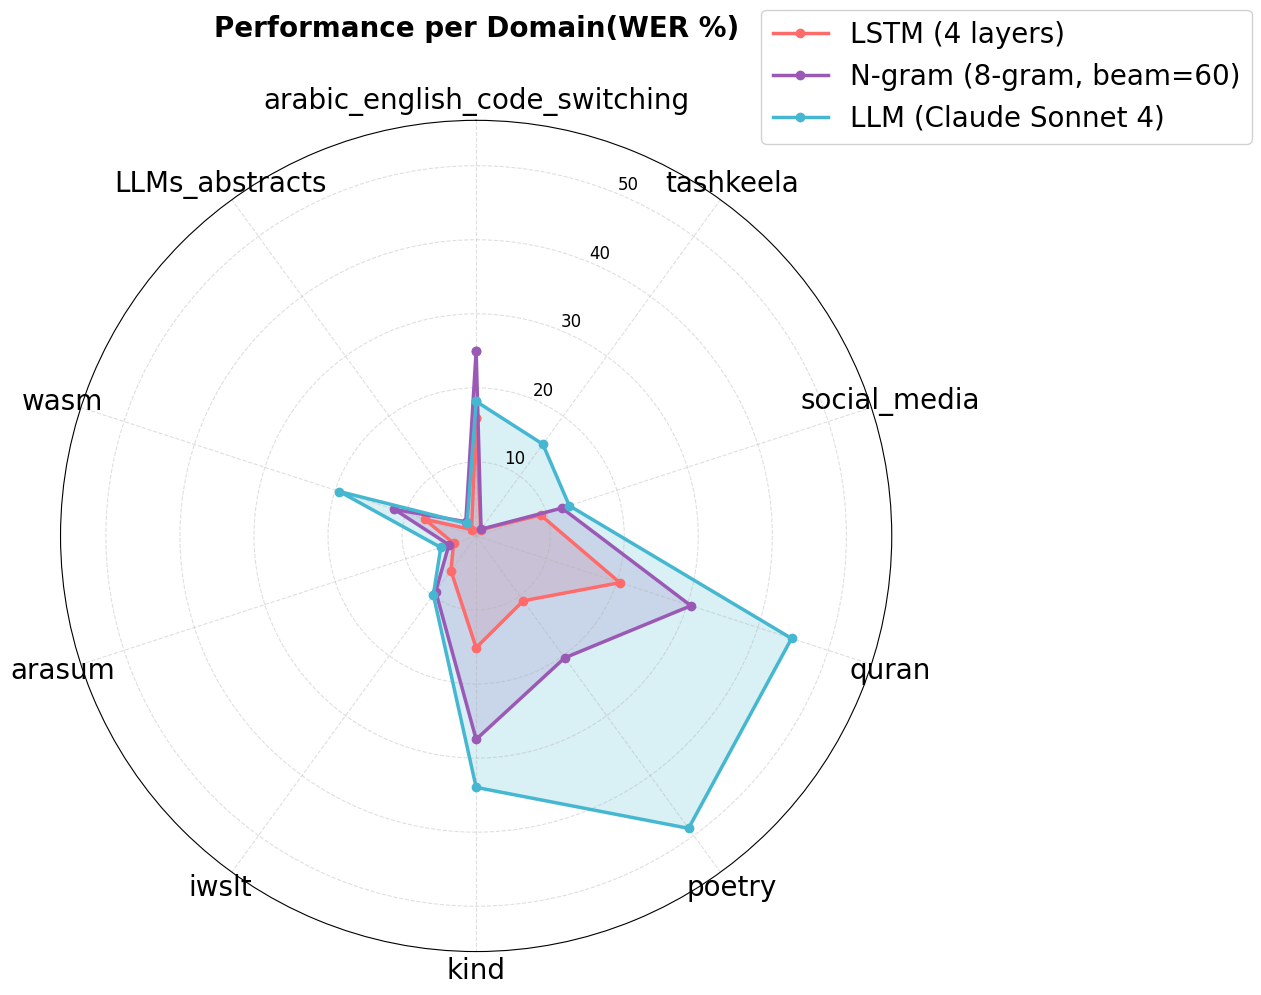

In [37]:
import matplotlib.pyplot as plt
from math import pi

# Prepare data for radar chart - CUSTOM ORDER TO SWAP wasm AND arabic_english_code_switching
domains = sorted(all_domains)[::-1]
# Find and swap wasm with arabic_english_code_switching
wasm_idx = domains.index('wasm')
aecs_idx = domains.index('arabic_english_code_switching')
domains[wasm_idx], domains[aecs_idx] = domains[aecs_idx], domains[wasm_idx]

num_domains = len(domains)

# Create figure - slightly wider to accommodate better spacing
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(projection='polar'))

# Compute angle for each axis
angles = [n / float(num_domains) * 2 * pi for n in range(num_domains)]
angles += angles[:1]  # Complete the circle

# Plot data for each model
colors = ['#FF6B6B', '#9B59B6', '#45B7D1']  # Red, Purple, Blue
for idx, (model_name, color) in enumerate(zip(results.keys(), colors)):
    values = []
    for domain in domains:
        if domain in all_domain_metrics[model_name]:
            values.append(all_domain_metrics[model_name][domain]['wer'])
        else:
            values.append(0)
    values += values[:1]  # Complete the circle
    
    ax.plot(angles, values, 'o-', linewidth=2.5, label=model_name, color=color, markersize=6)
    ax.fill(angles, values, alpha=0.2, color=color)

# Fix axis to go in the right order and start at 12 o'clock
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

# Set labels - INCREASED SIZE
ax.set_xticks(angles[:-1])
ax.set_xticklabels(domains, size=20)

# Set y-axis - NO LABEL
max_wer = max([max([all_domain_metrics[m][d]['wer'] for d in domains if d in all_domain_metrics[m]]) for m in results.keys()])
ax.set_ylim(0, max_wer * 1.15)

ax.tick_params(axis='y', labelsize=12)

# Add legend - MOVED UP TO REDUCE WHITE SPACE
plt.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), fontsize=20, framealpha=0.9)

# Add title
plt.title('Performance per Domain(WER %)', size=20, weight='bold', pad=60)

# Grid
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('tnqeet/notebooks/figures/dotting_models_domain_sensitivity.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

## Additional Analysis: Domain Statistics

In [8]:
# Calculate domain statistics across all models
domain_stats = []
for domain in sorted(all_domains):
    wer_values = []
    for model_name in results.keys():
        if domain in all_domain_metrics[model_name]:
            wer_values.append(all_domain_metrics[model_name][domain]['wer'])
    
    if wer_values:
        domain_stats.append({
            'Domain': domain,
            'Mean WER': np.mean(wer_values),
            'Std WER': np.std(wer_values),
            'Min WER': np.min(wer_values),
            'Max WER': np.max(wer_values),
            'Range': np.max(wer_values) - np.min(wer_values)
        })

df_stats = pd.DataFrame(domain_stats)
print("\nDomain Statistics Across All Models:")
print(df_stats.to_string(index=False))

# Find most challenging domains
print("\n" + "="*60)
print("Most Challenging Domains (by average WER):")
print("="*60)
for _, row in df_stats.nlargest(5, 'Mean WER').iterrows():
    print(f"{row['Domain']:40s} | Mean WER: {row['Mean WER']:6.2f}%")

print("\n" + "="*60)
print("Easiest Domains (by average WER):")
print("="*60)
for _, row in df_stats.nsmallest(5, 'Mean WER').iterrows():
    print(f"{row['Domain']:40s} | Mean WER: {row['Mean WER']:6.2f}%")


Domain Statistics Across All Models:
                       Domain  Mean WER   Std WER   Min WER   Max WER     Range
               LLMs_abstracts  1.834343  0.566698  1.050810  2.371975  1.321165
arabic_english_code_switching 19.687207  3.876252 15.884065 25.007853  9.123788
                       arasum  4.027597  0.752047  3.195427  5.017251  1.821824
                        iwslt  8.303158  1.789100  5.793047  9.833575  4.040528
                         kind 25.506260  7.823919 15.093856 33.953904 18.860048
                       poetry 26.658769 16.133975 10.826355 48.803775 37.977420
                        quran 31.897801 10.001223 20.407268 44.785367 24.378099
                 social_media 11.517656  1.728113  9.149817 13.225565  4.075748
                    tashkeela  5.831651  6.709884  1.051835 15.320773 14.268938
                         wasm 12.787922  5.006806  7.326891 19.421644 12.094753

Most Challenging Domains (by average WER):
quran                                 

## Bar Chart Comparison

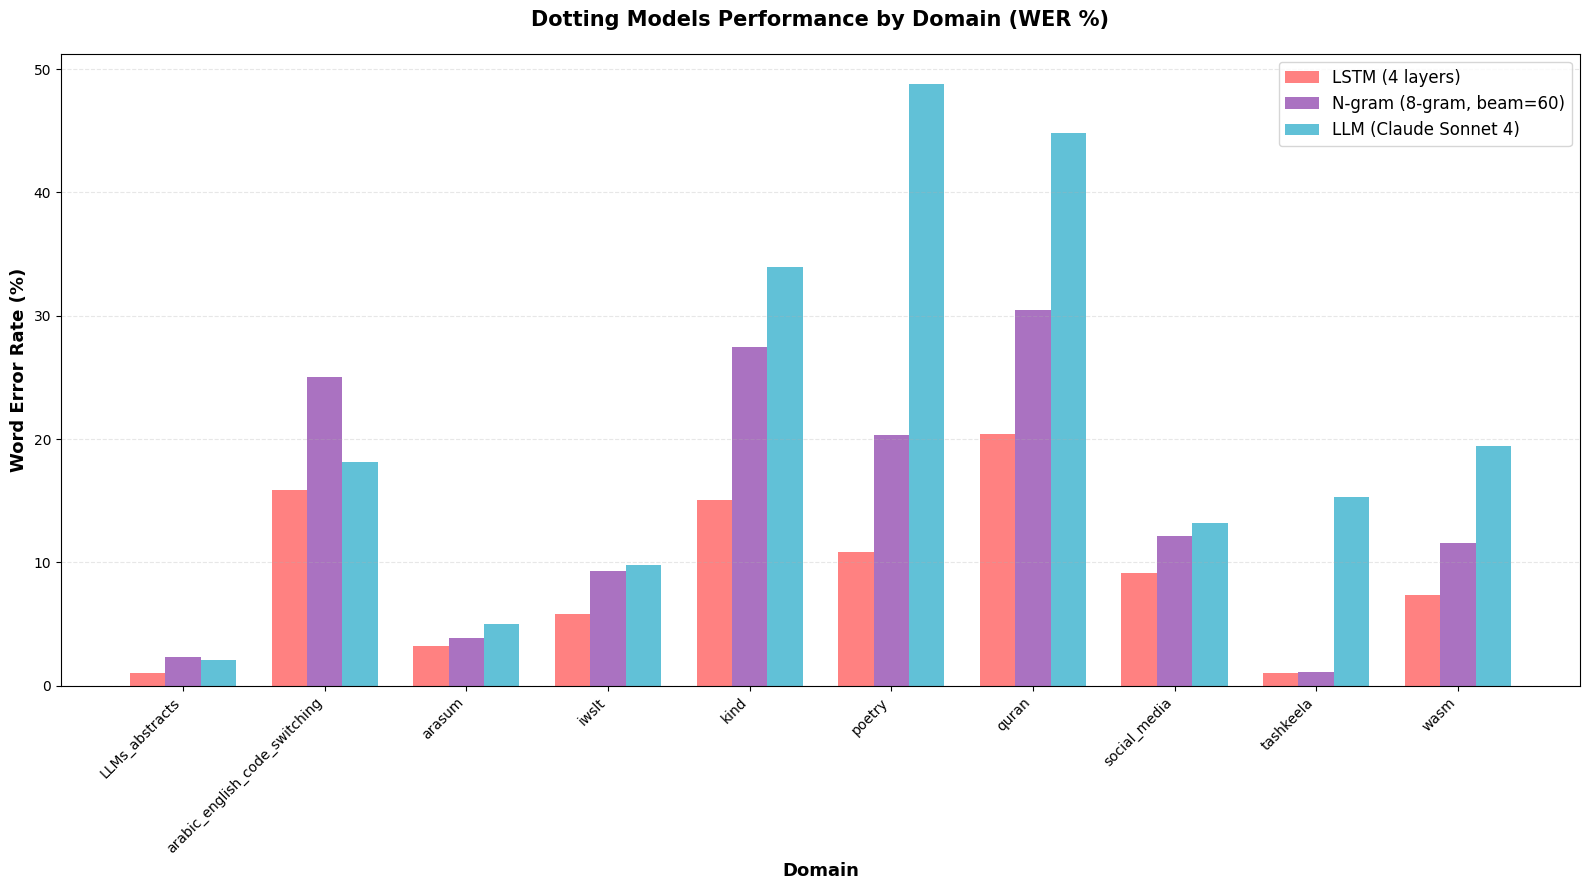

In [9]:
# Create grouped bar chart
fig, ax = plt.subplots(figsize=(16, 9))

x = np.arange(len(domains))
width = 0.25

for idx, (model_name, color) in enumerate(zip(results.keys(), colors)):
    values = []
    for domain in domains:
        if domain in all_domain_metrics[model_name]:
            values.append(all_domain_metrics[model_name][domain]['wer'])
        else:
            values.append(0)
    
    ax.bar(x + idx * width, values, width, label=model_name, color=color, alpha=0.85)

ax.set_xlabel('Domain', fontsize=13, weight='bold')
ax.set_ylabel('Word Error Rate (%)', fontsize=13, weight='bold')
ax.set_title('Dotting Models Performance by Domain (WER %)', fontsize=15, weight='bold', pad=20)
ax.set_xticks(x + width)
ax.set_xticklabels(domains, rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=12, loc='best')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('dotting_models_domain_comparison_bar.png', dpi=300, bbox_inches='tight')
plt.show()

## Overall Performance Summary

In [10]:
# Calculate overall metrics for each model
overall_metrics = []
for model_name, model_results in results.items():
    wer_values = [sample['wer'] for sample in model_results]
    cer_values = [sample['cer'] for sample in model_results]
    doer_values = [sample['doer'] for sample in model_results]
    
    overall_metrics.append({
        'Model': model_name,
        'WER (%)': np.mean(wer_values) * 100,
        'CER (%)': np.mean(cer_values) * 100,
        'DOER (%)': np.mean(doer_values) * 100,
        'Samples': len(model_results)
    })

df_overall = pd.DataFrame(overall_metrics)
print("\nOverall Performance Summary:")
print(df_overall.to_string(index=False))


Overall Performance Summary:
                   Model   WER (%)  CER (%)  DOER (%)  Samples
         LSTM (4 layers)  8.977937 1.830156  2.116590     5000
N-gram (8-gram, beam=60) 14.376592 2.827833  3.267162     5000
   LLM (Claude Sonnet 4) 21.061180 5.106409  5.871215     5000
